# Libreria computacional para calculo estadistico en Python: StatsModel

Tras haber visionado algun librerias de las mas importantes dentro de la actividad de gestion de datos en Python, como son Numpy y Pandas en la parte de  acceso y transformacion de datos, para posteriormente utilizar Seaborn en visualizacion y representacion de los datos, ahora vamos a ver una libreria que se desarrollo especificamente **para el calculo computacional estadistico** lo que conlleva la capacidad de crear modelos de prediccion en base a datos.

***StatsModel*** es una libreria que incluye clases y metodos para la estimacion de modelos estadisticos.

Permite definir modelos estadisticos a partir de **Dataframes de pandas, Numpy Arrays o Formulas de R**, por tanto es muy flexible en la capacidad de manipular datos provenientes de diferentes entornos.

> Esta construida sobre Numpy

Para poder operar con ella, sera necesario instalarla a traves de:

> ***pip install statsmodels***

In [1]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


## Principales funcionalidades de StatsModels

Esta libreria se utilizar principalmente para **gestionar modelos de regresion lineal**

> Estos modelos tienen como objetivo **generar una funcion con la cual podamos estimar valores futuros a partir de valores conocidos**

Aun siendo su principal funcion la aplicacion de las distintas formas de regresion lineal, no son sus unicas funciones o modelos de calculo estadistico. A continuacion de nombrar otros:

- ***Mixed Linear Model***: extension de los modelos lineales que incluye tanto efectos fijos y aleatorios.
> La principal diferencia es que se incluyen **valores aleatorios que permiten extender un poco mas el modelo a otras situaciones**
- ***GLM (Generalized Linear Model)***: es una generalizacion de los modelos de regresion lineal que incluye caracteristicas de otros modelos como el logistico o de regresion Poisson.
> Da mas opciones de estimacion que los modelos de regresion lineal **que no tienen una correlacion tan directa y no explica el comportamiento de los datos**
- ***GEE (Generalized Estimating Equations)***: permite estimar los parametros de un modelo GLM donde **existen una correlacion desconocida entre valores de salida.**
- ***Modelos discretos***: para conjuntos de datos aislados o no continuos, como en los modelos de regresion lineal.
- ***Analisis de Time Series***: aplicacion de analitica de datos continuos en un periodo de tiempo concreto. Busca patrones comunes en un periodo de tiempo dado
>*Time Series* recoge un conjunto de metricas que son continuos en el tiempo, permitiendo ver la evolucion.
>
> Por ejemplo el modelo ARIMA que es un modelo de prevision utilizando varios modelos de Time Series.
- ***Analisis de Supervivencia***: Rama de la estadistica que analiza la duracion en el tiempo de un evento

## Modelo de regresion lineal en StatsModel

Vistas las funcionalidades de creacion de modelos de la libreria en general, ahora vamos a centrarnos en el modelo mas extendido por excelencia para la estimacion con conjuntos de datos continuos: **La regresion lineal**

Este modelo nos dice que **existe una relacion lineal entre los valores de entrada (x) y los valores de salida (y)**

> Es por esta condicion de relacion-linea por lo que se llama *regresion lineal*
>
> Hay que tener en cuenta que segun este modelo, **siempre que tengamos los datos de entrada podremos representar graficamente los datos de salida**

La tecnica mas comun de regresion lineal es ***OLS( Ordinary Least Squares)*** y su formula es la siguiente:

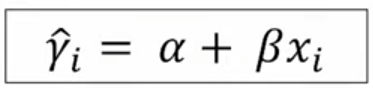

Y cada uno de los elementos nos indica lo siguiente:

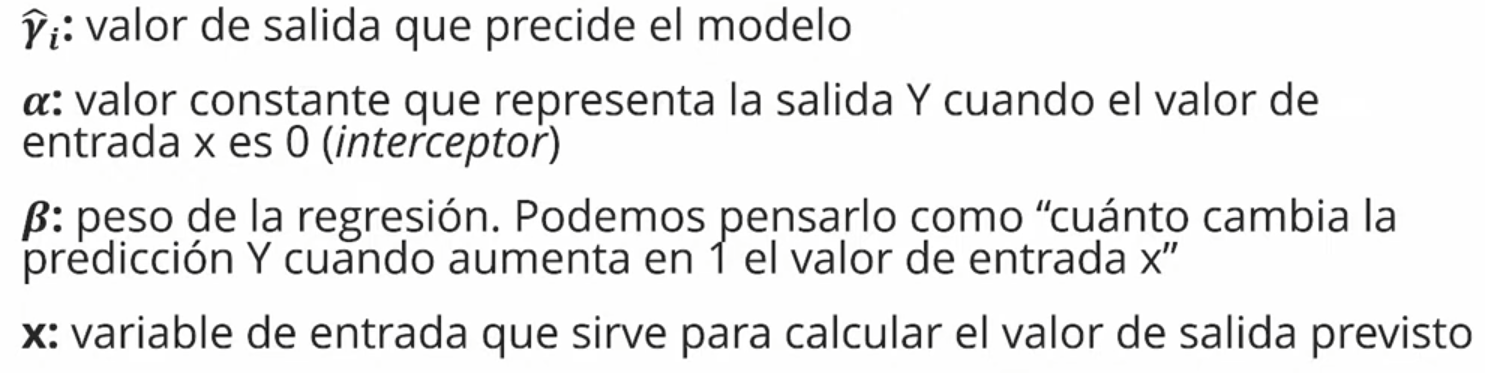

El otro elemento a tener en cuenta es **R2** que es **el porcentaje de variacion de la variable de respuesta que explica el modelo lineal**
> Tambien denominado *coeficiente de confianza* es un valor sobre **100%** y nos dice **como de bien se ajusta el modelo a realidad**, por lo que cuanto mas se acerque a 1, mejor ajuste tiene.
>

Para poder utilizar la libreria, primero deberemos importarla haciendo uso de ***import statsmodels.api***

> ***import statsmodels.api as sm***

### Ejemplo de creacion de regresion lineal

Para la creacion de un modelo de regresion lineal, debemos en primer lugar **cargar un dataframe con datos que nos permita elaborar la funcion**

En 2º lugar escribiremos una sentencia como esta:

> ***"nombre variable para modelo" = sm."nombre modelo"("nombre dataframe"["variable que queramos predecir o variable de salida"], "nombre dataframe"["variable de entrada o variable de prediccion"])
>
> > Es recomendable ademas añadir ***.fit()*** que permite ajustar el modelo a los datos

               SAT        GPA
count    84.000000  84.000000
mean   1845.273810   3.330238
std     104.530661   0.271617
min    1634.000000   2.400000
25%    1772.000000   3.190000
50%    1846.000000   3.380000
75%    1934.000000   3.502500
max    2050.000000   3.810000


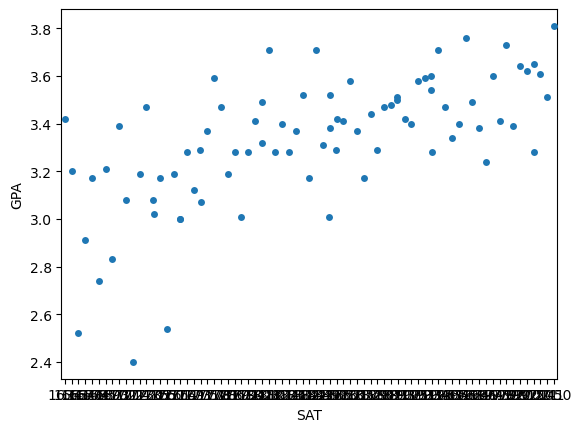

In [11]:
# 1º cargamos un dataset, creamos un dataframe y generamos un grafico de dispersion para visualizar los datos

from pathlib import Path
import pandas as pd
import seaborn as sns

RUTA = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U4_Libreria_StatsModels\students.csv")
df = pd.read_csv( RUTA)
print ( df[["SAT", "GPA"]].describe())
sns.stripplot(data = df, x= "SAT", y= "GPA").set(xlabel = "SAT", ylabel = "GPA");

In [16]:
#2º Comprobado que los datos no pueden permitir generar una regresion lineal, cargamos la libreria para poder generar una funcion.
# Haremos una funcion que revele como se comporta la funcion.

from pathlib import Path
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

RUTA = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U4_Libreria_StatsModels\students.csv")
df = pd.read_csv( RUTA)
modelo = sm.OLS(df["GPA"], df["SAT"]).fit()
print(modelo.summary())

                                 OLS Regression Results                                
Dep. Variable:                    GPA   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.996
Method:                 Least Squares   F-statistic:                          2.120e+04
Date:                Tue, 13 Jan 2026   Prob (F-statistic):                   9.38e-102
Time:                        10:33:45   Log-Likelihood:                          12.440
No. Observations:                  84   AIC:                                     -22.88
Df Residuals:                      83   BIC:                                     -20.45
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Como hemos visto, **si utilizamos el metodo *.summary()* podremos obtener una informacion detallada del comportamiento de la funcion**

> ***"nombre variable para modelo". summary()***

De entre todos los datos que obtenemos, **aquellos que adquieren un significado basico para entender la funcion** son:

- ***R2***: o *R-squared*, que nos dice como se ajusta la funcion a la realidad de los datos
- ***coef***: Que es el **factor multiplicador (o la *beta*) que se aplica a la X, o los datos de entrada, para obtener la estimacion**

                                 OLS Regression Results                                
Dep. Variable:                    GPA   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.996
Method:                 Least Squares   F-statistic:                          2.120e+04
Date:                Tue, 13 Jan 2026   Prob (F-statistic):                   9.38e-102
Time:                        11:48:50   Log-Likelihood:                          12.440
No. Observations:                  84   AIC:                                     -22.88
Df Residuals:                      83   BIC:                                     -20.45
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

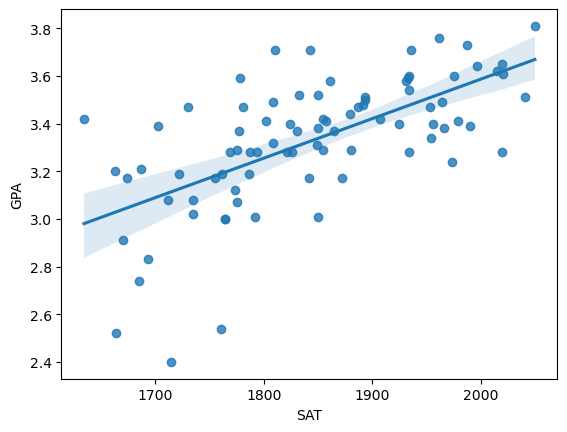

In [22]:
#3º Añadimos un grafico que muestre la regresion lineal, en este caso podemos utilizar sns.regplot()
# Genera en un grafico de dispersion la linea de regresion lineal de los datos

from pathlib import Path
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

RUTA = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U4_Libreria_StatsModels\students.csv")
df = pd.read_csv( RUTA)
modelo = sm.OLS(df["GPA"], df["SAT"]).fit()
print(modelo.summary())
sns.regplot(data = df, x= "SAT", y= "GPA").set(xlabel = "SAT", ylabel = "GPA");

Siempre que generemos una regresion lineal en statsmodel, **no nos va a dar la constante de la funcion, sino se la solicitamos explicitamente** para ello habra que utilizar la siguiente sentencia:

> ***"nombre variable para modelo" = sm.OLS("nombre dataframe"["variable que queramos predecir o variable de salida"], sm.add_constant("nombre dataframe"["variable de entrada o variable de prediccion"]))
>
> > Si hacemos *.summary()* veremos que aparece **una linea adicional que define el valor de la constante en *coef***

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     56.05
Date:                Tue, 13 Jan 2026   Prob (F-statistic):           7.20e-11
Time:                        11:55:05   Log-Likelihood:                 12.672
No. Observations:                  84   AIC:                            -21.34
Df Residuals:                      82   BIC:                            -16.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2750      0.409      0.673      0.5

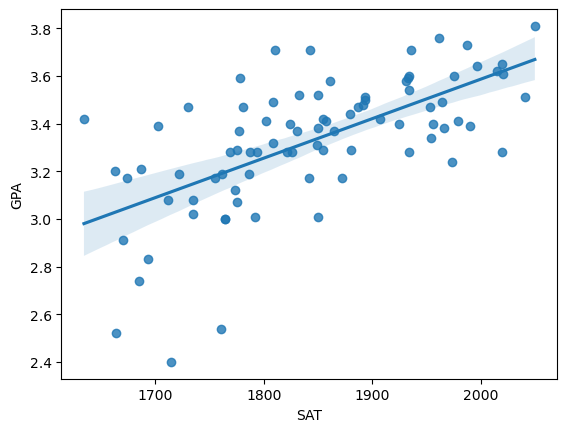

In [23]:
#4º Añadimos una constante en la formulacion, para que la funcion no solo disponga de coeficiente.

from pathlib import Path
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

RUTA = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U4_Libreria_StatsModels\students.csv")
df = pd.read_csv( RUTA)
modelo = sm.OLS(df["GPA"], sm.add_constant( df["SAT"])).fit()
print(modelo.summary())
sns.regplot(data = df, x= "SAT", y= "GPA").set(xlabel = "SAT", ylabel = "GPA");

Por ultimo, una vez hemos obtenido una funcion, que hayamos evalaudo, **podemos realizar predicciones en base a esta funcion con el metodo *.predict()***

> ******"nombre variable para modelo" = sm.OLS("nombre dataframe"["variable que queramos predecir o variable de salida"], sm.add_constant("nombre dataframe"["variable de entrada o variable de prediccion"])).predict("nuevos datos de entrada con los que probar la funcion")
>
> > Como es evidente, **es necesario utilziar nuevos datos de entrada para probar la funcion de estimacion**

### Consideraciones de las regresiones lineales:

A modo de resumen, indico aqui algunos aspectos a tener en cuenta al realizar las regresiones lineales:

- Para crear la sentencia **se puede o no incluir una constante** en los parametros.
- Para visualizar los datos utilizaremos la sentencia ***.summary()***
- Lo importante al revisar los resultados sera ver el***R2*** y el***coef*** que multiplica a la X
- el***R2*** **es *inflado artificialmente* sino se solicita una constante en la formulacion**
> Esto es debido a que el *coef* por la que se multiplica X, si es 0, el valor de la funcion sera 0.
>
> > Es importante conocer esto porque la funcion resultante **puede ser interesante hacerla con o sin constante, ya que puede tener un valor de estimacion mas adecuado** 

### Visualizacion de nuestras regresiones lineales mediante Matplotlib

Por ultimo, pese a que los ejemplos los hemos hecho con Seaborn y sus funciones, **el unico modo de representar visualmente funciones desarrolladas en statsmodels es a traves de *Matplotlib***

Por ello, es neecsario entender como se relacionan estas 2 librerias.

En primer lugar ***Statsmodels*** esta basada en ***Matplotlib*** por lo que hace uso de sus graficos para las representaciones de figuras.

Para poder realizar las representaciones, hay que importar Matplotlib al entorno:

> ***import matplotlib.pyplot as plt***

Para poder crear las representaciones se utilizan sentencias asi:

> ***plt.figure(figzise = ("ancho del grafico" , "largo del grafico"), edegecolor = "nombre del color", facecolor = "nombre del color)***
>
> > Permite tambien generar **superposicion de figuras en un mismo grafico compartiendo eje x** usando sentencias como ***plt.subplots()***

Algunos graficos disponibles son:

- ***plt.barh()***: Grafico con barras horizontales
- ***plt.bar()***: Grafico con barras verticales
- ***plt.piep()***: Grafico circular
- ***plt.plot()***: Grafico de lineas
- ***plt.scatter()***: Grafico de dispersion
> Es posible incluir graficos en 3D mediante parametros como ***projection = "3D"***

Por ultimo, para que se muestren en pantalla simepre hay que incluir la sentencia:

> ***plt.show()***

## Generacion de otros modelos estadisticos

Aunque con el modelo de regresion lineal podremos abarcar un numero de predicciones amplio, tal y como hemos visto antes, **hay muchos mas modelos disponibles en la libreria**

A continuacion intentaremos definir mas modelos a traves de formulas de estimacion estadistica.

> Por ejemplo, cuando se quiere probar diferentes hipotesis conlleva **probar distintas variables ( quitar o añadir, considerar interacciones o transformaciones) y realizar una *matriz* para cada alternativa**

Para ello traeremos al entorno **una API con soporte para formulas**

> ***import statsmodels.formula.api as smf***

Una vez traida la sentencia para generar una formula seria parecida a esta:

> ***smf.ols( formula = " variable que queremos predecir o salida ~ "variable de entrada" + "variable de entrada" ..." , data = "nombre dataframe")***
>
> > Es interesante ya que la formulacion **se hace textual y resulta mas facil de comprender**, haciendo que sea mas facil y rapido de interpretar.
> >
> > Ademas **incluye ademas una constante, aunque no se lo pidamos explicitamente**

Por ultimo, al igual que ocurre en *R* hay algunas reglas a entender para la formulacion:

- **Eliminar un termino o variable se realiza mediante *una resta***

> ***smf.ols( formula = " variable que queremos predecir o salida ~ "variable de entrada" + "variable de entrada"... - "numero de variables a eliminar" , data = "nombre dataframe")***

- **Se pueden añadir *la interaccion (la multiplicacion)* entre 2 variables, haciendo que se añadan a la suma de variables o que solo se tenga en cuenta el producto de las mismas**

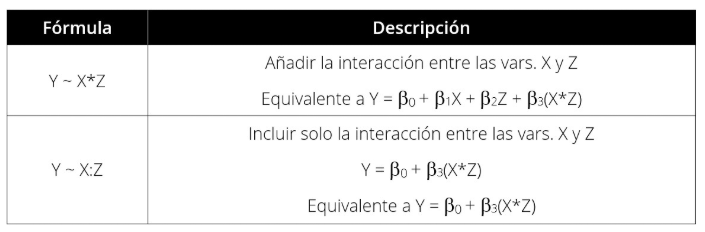